In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [2]:
df = pd.read_csv("../data/processed/final_financial_data.csv")

df["Transaction_Date"] = pd.to_datetime(
    df["Transaction_Date"],
    format="mixed",
    dayfirst=True
)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (9802, 25)


,Transaction_ID,Transaction_Date,Company_Code,Cost_Center,Profit_Center,Account_Category,Transaction_Type,Amount,Budget,Payment_Status,...,Vendor_ID,Tax_Amount,Profit,Approval_Status,Anomaly_Indicator,Year,Month,Quarter,Budget_Variance,Budget_Utilization
0,TX005450,2024-01-17,C003,CC107,PC206,Procurement,Expense,660134.88,870600.30,Pending,...,NaN,115121.44,NaN,Approved,0,2024,1,1,-210465.42,75.825253
1,TX000061,2021-01-21,C001,CC111,PC202,Marketing,Expense,226317.84,255507.62,Paid,...,V040,42898.57,NaN,Approved,0,2021,1,1,-29189.78,88.575769
2,TX007730,2025-10-02,C002,CC105,PC206,Marketing,Expense,381300.39,427732.69,Partially Paid,...,V035,70826.38,NaN,Approved,0,2025,10,4,-46432.30,89.144552
3,TX003695,2023-02-14,C002,CC112,PC204,Procurement,Expense,352712.21,360120.03,Partially Paid,...,V001,62394.66,NaN,Approved,0,2023,2,1,-7407.82,97.942958
4,TX001800,2022-02-25,C005,CC104,PC206,Sales,Revenue,599713.69,603576.07,Paid,...,NaN,109719.59,164961.87,Pending,0,2022,2,1,-3862.38,99.360084


In [3]:
df["Anomaly_Indicator"].value_counts()

Anomaly_Indicator
0    9607
1     195
Name: count, dtype: int64

In [4]:
features = [
    "Amount",
    "Budget",
    "Quantity",
    "Tax_Amount",
    "Budget_Variance",
    "Budget_Utilization"
]

X = df[features].copy()

X.head()

,Amount,Budget,Quantity,Tax_Amount,Budget_Variance,Budget_Utilization
0,660134.88,870600.30,653.0,115121.44,-210465.42,75.825253
1,226317.84,255507.62,1.0,42898.57,-29189.78,88.575769
2,381300.39,427732.69,1.0,70826.38,-46432.30,89.144552
3,352712.21,360120.03,319.0,62394.66,-7407.82,97.942958
4,599713.69,603576.07,450.0,109719.59,-3862.38,99.360084


In [6]:
X.info()

X.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9802 entries, 0 to 9801
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Amount              9802 non-null   float64
 1   Budget              9802 non-null   float64
 2   Quantity            9802 non-null   float64
 3   Tax_Amount          9802 non-null   float64
 4   Budget_Variance     9802 non-null   float64
 5   Budget_Utilization  9802 non-null   float64
dtypes: float64(6)
memory usage: 459.6 KB


Amount                0
Budget                0
Quantity              0
Tax_Amount            0
Budget_Variance       0
Budget_Utilization    0
dtype: int64

In [7]:
isolation_model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

isolation_model.fit(X)

print("Isolation Forest model trained successfully.")

Isolation Forest model trained successfully.


In [8]:
df["Model_Anomaly"] = isolation_model.predict(X)

df["Model_Anomaly"] = df["Model_Anomaly"].map({
    1: 0,
    -1: 1
})

df["Model_Anomaly"].value_counts()

Model_Anomaly
0    9605
1     197
Name: count, dtype: int64

In [9]:
comparison = pd.crosstab(
    df["Anomaly_Indicator"],
    df["Model_Anomaly"],
    rownames=["Actual Anomaly"],
    colnames=["Model Prediction"]
)

comparison

Model Prediction,0,1
Actual Anomaly,,
0,9482,125
1,123,72


In [10]:
precision = 72 / (72 + 125)
recall = 72 / (72 + 123)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1_score, 4))

Precision: 0.3655
Recall: 0.3692
F1-Score: 0.3673


In [11]:
detected_anomalies = df[df["Model_Anomaly"] == 1].copy()

detected_anomalies[
    [
        "Transaction_ID",
        "Transaction_Date",
        "Transaction_Type",
        "Amount",
        "Budget",
        "Budget_Variance",
        "Budget_Utilization",
        "Anomaly_Indicator",
        "Model_Anomaly"
    ]
].sort_values(
    by="Amount",
    ascending=False
).head(20)

,Transaction_ID,Transaction_Date,Transaction_Type,Amount,Budget,Budget_Variance,Budget_Utilization,Anomaly_Indicator,Model_Anomaly
8608,TX008393,2025-06-23,Expense,10632863.20,1096135.65,9536727.55,970.031693,0,1
8565,TX008487,2025-06-18,Expense,9887382.80,949746.14,8937636.66,1041.055329,0,1
8402,TX008334,2025-05-23,Revenue,9691773.30,1364760.91,8327012.39,710.144409,0,1
4912,TX004865,2023-09-28,Revenue,8989954.30,1242636.81,7747317.49,723.457910,0,1
4217,TX004226,2023-05-16,Revenue,8749021.80,962222.39,7786799.41,909.251530,0,1
8255,TX008083,2025-04-27,Revenue,8163372.40,670886.58,7492485.82,1216.803651,0,1
9030,TX008885,2025-09-08,Revenue,8058331.80,787188.86,7271142.94,1023.684685,0,1
9430,TX009365,2025-11-14,Revenue,6523453.40,765602.18,5757851.22,852.068290,1,1
7479,TX007280,2024-12-19,Expense,5685453.60,629349.50,5056104.10,903.385734,0,1
7007,TX007054,2024-10-06,Revenue,5637651.20,412916.42,5224734.78,1365.325021,0,1


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,Amount,Budget,Quantity,Tax_Amount,Budget_Variance,Budget_Utilization
0,0.958912,2.170851,1.681557,1.468868,-0.749069,-0.386757
1,-0.104949,-0.014127,-0.467733,0.089966,-0.132116,-0.228558
2,0.275119,0.597664,-0.467733,0.623172,-0.190799,-0.221501
3,0.205011,0.357485,0.580541,0.462191,-0.057983,-0.112338
4,0.810740,1.222308,1.012376,1.365734,-0.045916,-0.094755


In [13]:
isolation_model_scaled = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

isolation_model_scaled.fit(X_scaled)

print("Scaled Isolation Forest model trained successfully.")

Scaled Isolation Forest model trained successfully.


In [14]:
df["Model_Anomaly_Scaled"] = isolation_model_scaled.predict(X_scaled)

df["Model_Anomaly_Scaled"] = df["Model_Anomaly_Scaled"].map({
    1: 0,
    -1: 1
})

df["Model_Anomaly_Scaled"].value_counts()

Model_Anomaly_Scaled
0    9605
1     197
Name: count, dtype: int64

In [ ]:
comparison_scaled = pd.crosstab(
    df["Anomaly_Indicator"],
    df["Model_Anomaly_Scaled"],
    rownames=["Actual Anomaly"],
    colnames=["Model Prediction"]
)

comparison_scaled

Model Prediction,0,1
Actual Anomaly,,
0,9482,125
1,123,72


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_scaled = precision_score(
    df["Anomaly_Indicator"],
    df["Model_Anomaly_Scaled"]
)

recall_scaled = recall_score(
    df["Anomaly_Indicator"],
    df["Model_Anomaly_Scaled"]
)

f1_scaled = f1_score(
    df["Anomaly_Indicator"],
    df["Model_Anomaly_Scaled"]
)

print("Scaled Model Precision:", round(precision_scaled, 4))
print("Scaled Model Recall:", round(recall_scaled, 4))
print("Scaled Model F1-Score:", round(f1_scaled, 4))

Scaled Model Precision: 0.3655
Scaled Model Recall: 0.3692
Scaled Model F1-Score: 0.3673


In [17]:
df["Final_Anomaly"] = df["Model_Anomaly"]

df["Final_Anomaly"].value_counts()

Final_Anomaly
0    9605
1     197
Name: count, dtype: int64

In [18]:
anomaly_summary = pd.DataFrame({
    "Metric": [
        "Total Transactions",
        "Reference Anomalies",
        "Model Detected Anomalies",
        "True Positive Anomalies"
    ],
    "Value": [
        len(df),
        df["Anomaly_Indicator"].sum(),
        df["Final_Anomaly"].sum(),
        (
            (df["Anomaly_Indicator"] == 1) &
            (df["Final_Anomaly"] == 1)
        ).sum()
    ]
})

anomaly_summary

,Metric,Value
0,Total Transactions,9802
1,Reference Anomalies,195
2,Model Detected Anomalies,197
3,True Positive Anomalies,72


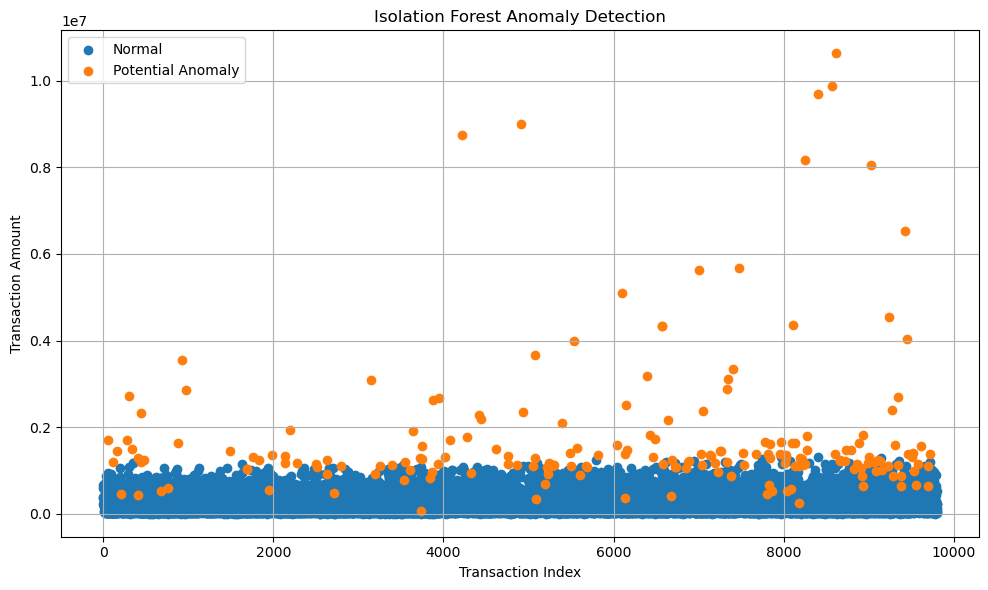

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df.index[df["Final_Anomaly"] == 0],
    df.loc[df["Final_Anomaly"] == 0, "Amount"],
    label="Normal"
)

plt.scatter(
    df.index[df["Final_Anomaly"] == 1],
    df.loc[df["Final_Anomaly"] == 1, "Amount"],
    label="Potential Anomaly"
)

plt.title("Isolation Forest Anomaly Detection")
plt.xlabel("Transaction Index")
plt.ylabel("Transaction Amount")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
output_columns = [
    "Transaction_ID",
    "Transaction_Date",
    "Company_Code",
    "Cost_Center",
    "Profit_Center",
    "Account_Category",
    "Transaction_Type",
    "Amount",
    "Budget",
    "Payment_Status",
    "Department",
    "Currency",
    "Tax_Amount",
    "Profit",
    "Approval_Status",
    "Anomaly_Indicator",
    "Final_Anomaly"
]

anomaly_results = df[output_columns].copy()

anomaly_results.to_csv(
    "../data/processed/anomaly_detection_results.csv",
    index=False
)

print("Anomaly detection results saved successfully.")

Anomaly detection results saved successfully.


In [23]:
joblib.dump(
    isolation_model,
    "../models/isolation_forest_anomaly_model.pkl"
)

print("Isolation Forest model saved successfully.")

Isolation Forest model saved successfully.
